In [16]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mizard\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [18]:
df=pd.read_csv('data_manual.csv')
print(df)

          source                                 review_description  rating  \
0      App Store  I’m excited for this app but the MAJORITY of m...       1   
1    Google Play  First downloader so follow me Insta id. sam_as...       5   
2    Google Play                                     Not bad at all       1   
3    Google Play                               Needed some new app.       5   
4    Google Play  Haven't used the app yet but from what I see f...       5   
..           ...                                                ...     ...   
495  Google Play                     Very impressed I like this app       5   
496  Google Play                      Innovate something you theifs       1   
497  Google Play  Very disappointed,first of all we can't logout...       1   
498  Google Play  This app has potential, but it needs an explor...       3   
499  Google Play  Bug where instagram link not appear when visit...       4   

             review_date sentiment  
0    2023-07-0

In [19]:
# 1. Preprocessing
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def tokenize(text):
    return text.split()

def stemming(tokens):
    return [ps.stem(word) for word in tokens if word not in stop_words]

def lemmatization(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

df['cleaned'] = df['review_description'].apply(clean_text)
df['tokens'] = df['cleaned'].apply(tokenize)
df['stemmed_tokens'] = df['tokens'].apply(stemming)
df['lemma_tokens'] = df['tokens'].apply(lemmatization)

df['stemmed_text'] = df['stemmed_tokens'].apply(lambda x: ' '.join(x))
df['lemma_text'] = df['lemma_tokens'].apply(lambda x: ' '.join(x))

In [20]:
# 2. Feature Extraction Setup

# A. BoW & TF-IDF
tfidf_vec = TfidfVectorizer(max_features=1000)
bow_vec = CountVectorizer(max_features=1000)

X_tfidf = tfidf_vec.fit_transform(df['lemma_text']).toarray()
X_bow = bow_vec.fit_transform(df['lemma_text']).toarray()

# B. Word2Vec
w2v_model = Word2Vec(sentences=df['lemma_tokens'], vector_size=100, window=5, min_count=1, workers=1)

def get_mean_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([get_mean_vector(tokens, w2v_model) for tokens in df['lemma_tokens']])

In [21]:
# 3. K-Means

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans.fit(X_tfidf)
print(kmeans.labels_)

[0 3 3 3 3 3 3 4 1 3 3 2 3 3 3 3 4 3 3 2 3 3 3 3 3 2 2 3 4 3 3 0 3 2 3 2 0
 4 2 3 0 2 2 3 1 0 2 3 3 3 2 3 3 3 2 3 1 3 3 2 0 0 0 3 3 2 0 3 2 3 4 2 3 2
 2 0 3 2 2 3 2 0 0 3 3 3 3 0 3 2 3 3 3 2 3 2 3 3 2 3 0 3 2 3 3 1 3 3 3 3 3
 0 0 3 0 2 3 0 3 1 3 3 3 2 0 0 2 3 0 0 1 1 3 0 3 2 4 3 3 3 3 3 3 1 0 3 3 3
 2 3 3 3 3 0 2 2 2 3 3 3 0 0 2 2 2 3 3 2 3 3 2 1 3 3 2 2 3 3 3 0 3 3 3 3 0
 3 3 4 3 3 2 3 3 2 3 0 3 1 4 0 3 2 2 2 3 2 3 3 3 2 3 0 2 3 3 3 0 3 3 3 3 0
 3 1 0 3 2 2 0 1 3 3 2 2 3 3 0 4 2 3 3 1 2 0 3 4 4 3 0 2 3 3 3 1 0 2 1 3 3
 2 3 3 0 2 2 0 0 2 2 3 4 0 3 0 0 3 0 0 0 1 3 0 0 3 2 3 2 4 3 2 2 2 3 0 1 2
 3 3 2 3 0 2 3 2 2 1 3 3 2 1 2 2 0 2 2 0 1 3 0 3 3 1 3 2 2 0 3 0 3 3 1 3 3
 2 1 2 3 3 1 2 4 3 3 0 3 2 3 3 2 0 2 3 3 0 1 0 3 3 3 3 4 3 0 1 0 3 3 0 0 2
 2 3 0 0 1 3 2 2 3 3 4 0 3 3 3 2 3 1 2 3 2 2 3 3 3 1 2 3 0 0 2 0 0 0 3 0 2
 0 3 3 3 3 0 3 3 3 2 3 3 2 3 0 3 3 3 0 3 1 3 3 2 3 3 0 2 3 3 3 3 3 3 3 0 3
 3 3 3 0 3 3 0 3 3 3 0 2 2 3 3 2 0 0 3 3 0 3 2 0 3 2 2 0 3 3 3 2 0 0 0 3 0
 4 3 1 3 1 3 2 2 3 2 2 3 

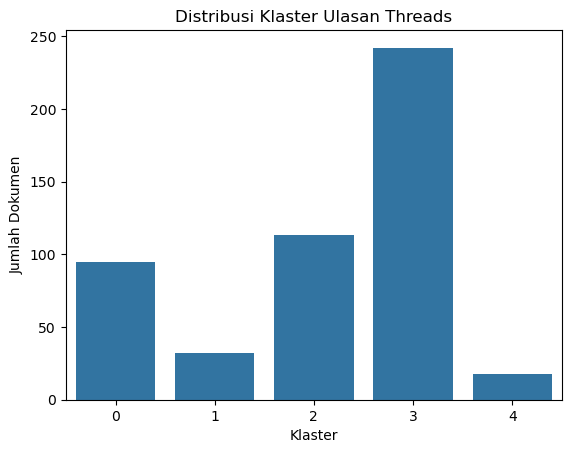

In [22]:
df['cluster'] = kmeans.labels_
sns.countplot(x='cluster', data=df)
plt.title('Distribusi Klaster Ulasan Threads')
plt.xlabel('Klaster')
plt.ylabel('Jumlah Dokumen')
plt.show()

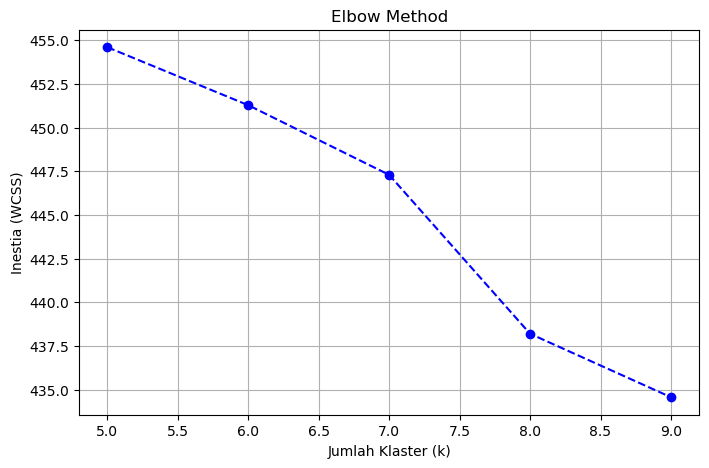

In [25]:
# Elbow Method

inertia_values = []
K = range(5, 10)

for k in K:
    kmeans = KMeans(n_clusters = k, random_state=42, n_init=10)
    kmeans.fit(X_tfidf)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Method')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Inestia (WCSS)')
plt.grid(True)
plt.show()